# MVP: *Machine Learning & Analytics* - Pós-Graduação PUC-RIO
### MVP apresentado como atividade final da Sprint Machine Learning & Analytics

**Autor:** Rogério dos Santos Ferreira  

**Data:** 27/08/2025

**Matrícula:** 4052025001195

**Dataset:** [Hypertension Risk Prediction Dataset](https://www.kaggle.com/datasets/miadul/hypertension-risk-prediction-dataset)

Criação de modelo de Machine Learning destinado à classificação de risco de quadro de hipertensão.

Objetivo: Aplicação em dispositivos de monitoramento físico e aplicativos de treinamento físico.

Este conjunto de dados sintéticos, porém realistas, foi criado para auxiliar pesquisadores, cientistas de dados e entusiastas da saúde a analisar os fatores de risco associados à hipertensão (pressão alta). Ele contém 1.985 registros e 11 recursos significativos gerados com base em insights clínicos e padrões de dados de saúde pública.

| Variável | Descrição |
| :---: | --- |
| Age | Idade do paciente (em anos) |
| Salt_Intake | Ingestão diária de sal (em gramas) – um dos principais fatores que contribuem para a pressão alta |
| Stress_Score | Escala de 0 a 10 que mede o nível de estresse psicológico |
| BP_History | Estado pressórico anterior: Normal, Pré-hipertensão, Hipertensão |
| Sleep_Duration | Média de horas de sono por dia |
| BMI | Índice de Massa Corporal (medida de obesidade baseada em peso/altura) |
| Medication | Tipo de medicação: Nenhum, Betabloqueador, Diurético, Inibidor da ECA, Outro |
| Family_History | Histórico familiar de hipertensão: Sim/Não |
| Exercise_Level | Nível de atividade física: Baixo, Moderado, Alto |
| Smoking_Status | Se o paciente é fumante ou não fumante |
| Has_Hypertension | Variável-alvo: Indica a presença de hipertensão (Sim/Não) |

Fonte: https://www.kaggle.com/datasets/miadul/hypertension-risk-prediction-dataset

<a href="https://colab.research.google.com/github/rogerioferreira/MVP-Machine_Learnin-PUC-RIO/blob/main/notebooks/hypertension_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importação das bibliotecas necessárias para o projeto

In [1341]:
# importação de bibliotecas básicas
import os
import sys
import time
import joblib
import locale
import random
import warnings
import numpy as np
import pandas as pd
import plotly.io as pio
import plotly.express as px
from scipy.stats import randint

# importação de métodos de tratamento
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import GridSearchCV

# from sklearn.model_selection import RandomizedSearchCV

# importação de métodos de pré-processamento
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# importação de modelos
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# importação de ensembles
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

# importação de métricas de avaliação
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

# importação de ferramentas para construção de pipelines
from sklearn.pipeline import Pipeline

# configuração para não exibir warnings
warnings.filterwarnings("ignore")

# configuração de locale para pt-BR
locale.setlocale(locale.LC_ALL, "pt_BR.UTF-8")

# configuração para definição de tema, cores e tamanho padrão dos gráficos no Plotly
# Plotly themes ["plotly", "plotly_white", "plotly_dark", "ggplot2", "seaborn", "simple_white", "none"]
pio.templates.default = "plotly"

# atribui a configuração para exportação de gráficos do plotly
# ["notebook", "png"]
pio.renderers.default = "png"


# definição da semente aleatória visando a reprodutibilidade
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Para frameworks que suportam seed adicional (ex.: PyTorch/TensorFlow), documente aqui:
# import torch; torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
# import tensorflow as tf; tf.random.set_seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)

# Bibliotecas adicionais
# imbalanced-learn xgboost lightgbm catboost optuna

Python: 3.12.11
Seed global: 42


### Funções auxiliares

Definição de funções auxiliares para reutilização do código como boa prática de programação.

In [1342]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Função para avaliação de modelos de classificação.
    Parâmetros:
    y_true: array-like, rótulos verdadeiros
    y_pred: array-like, rótulos previstos
    proba: array-like, probabilidades previstas (opcional)
    Retorna:
    dict: dicionário com as métricas de avaliação"""

    accu = accuracy_score(y_true, y_pred)
    f1s = f1_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="weighted")
    prec = precision_score(y_true, y_pred, average="weighted")
    auc = (
        roc_auc_score(y_true, proba[:, 1])
        if (proba is not None and proba.shape[1] == 2)
        else np.nan
    )
    return {
        "accuracy": accu,
        "f1_score": f1s,
        "recall_score": rec,
        "precision_score": prec,
        "roc_auc": auc,
    }

## Obtenção, análise e tratamento dos dados

In [1343]:
# carga dos dados
data_path = "../dados/hypertension_dataset.csv"
url = "https://raw.githubusercontent.com/rogerioferreira/MVP-Machine_Learning-PUC-RIO/refs/heads/main/dados/hypertension_dataset.csv"

if os.path.exists(data_path):
    # caraga do dataset localmente, caso presente
    df = pd.read_csv(data_path, delimiter=",")
else:
    # caraga do dataset diretamente pelo Git Hub
    df = pd.read_csv(url, delimiter=",")

# observações iniciais
display(df.head(3))
print(f"Formato: {df.shape}\n")
print(f"{df.info()}\n")

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No


Formato: (1985, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB
None



### Verificação da ocorrência de dados nulos no dataframe

Foi oservada a presença de valores nulos no registro do uso de medicação continuada para uma parcela significativa das ocorrências (40% dos casos), contudo, conforme descrição constante nos próprios metadados no Kaggle, o tipo de medicação subdivide-se em Nenhum, Betabloqueador, Diurético, Inibidor da ECA ou Outro, contudo, percebeu-se que os registros nulos referiam-se à ausência de medicação, desta forma, o procedimento adotado foi a substituição dos campos nulos com a atribuição do valor "No Medication", de forma a viabilizar de maneira adequada o emprego da informação no treinamento do modelo.

Tal decisão ampara-se na visão de Aurélien Géron que afirma que para dados categóricos, uma das abordagens para lidar com valores ausentes é a imputação, onde os valores faltantes são preenchidos. Uma vez que os dados categóricos não têm um valor numérico para o qual você possa calcular a média ou a mediana, o preenchimento pode ser feito com a categoria mais frequente (moda) ou com um valor constante, como 'desconhecido'. Uma abordagem comum para atributos categóricos é tratar os valores ausentes como uma categoria separada, como "Missing" ou "Unknown" (Géron, 2022).

In [1344]:
# verificação da presença de valores nulos
df.isnull().sum()

Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64

In [1345]:
# calculo do percentual de dados nulos
percentual = (df["Medication"].isnull().sum() / len(df)) * 100
print(f"Percentual de dados nulos: {percentual:.2f}%")

Percentual de dados nulos: 40.25%


In [1346]:
# verificação das categorias existentes na coluna Medication
df["Medication"].unique().tolist()

[nan, 'ACE Inhibitor', 'Other', 'Beta Blocker', 'Diuretic']

In [1347]:
# atribuição de informação de não uso de medicação para os registros nulos - incluída no pipeline
# df["Medication"].fillna("No Medication", inplace=True)

### Verificação de dados duplicados no dataframe

A existência de dados duplicados em um dataframe de treinamento de machine learning pode ter um impacto significativo nos modelos. A duplicação pode distorcer a importância de certas observações, fazendo com que o modelo considere essas instâncias mais importantes do que realmente são. Isso pode levar a um viés no treinamento, onde o modelo dá mais peso a padrões repetidos, afetando sua capacidade de generalizar para novos dados (Mukhopadhyay, 2018).

Neste sentido, foi realizada a averiguação quanto a existência de ocorrências duplicadas no conjunto de dados, contudo, não foram observadas ocorrências de duplicidades nos mesmos.

In [1348]:
# verificação da presença de dados duplicados
print(f"Identificação de duplicatas: {df.duplicated().any()}")

# verificação da quantidade de entradas duplicadas no dataframe
print(f"Quantidade de registro duplicados: {df.duplicated().sum()}")

Identificação de duplicatas: False
Quantidade de registro duplicados: 0


### Verificação da existência de outliers

Outliers são pontos de dados com valores muito diferentes da maioria dos outros pontos do conjunto de dados. Eles podem ser observações genuínas, mas também podem ser resultado de erros de medição, erros de entrada de dados ou problemas no processo de coleta. A existência de outliers pode afetar o desempenho de certos algoritmos, especialmente os que são sensíveis a variações nos dados, como a regressão linear e as máquinas de vetores de suporte (SVMs). Esses pontos extremos podem influenciar o modelo a aprender um padrão que não representa a maioria dos dados, levando a um desempenho ruim em novos dados (BROWNLEE, 2016).

Contudo, Nem todos os dados que parecem estar fora de uma distribuição normal de dados são necessariamente outliers. É importante entender a causa do valor atípico para decidir como tratá-lo. Por exemplo, um valor pode ser extremo, mas ser uma observação legítima e importante para o seu modelo (GÉRON, 2022).

Desta forma, foram analisadas as variáveis Idade, Ingestão Diária de Sal, Escala de Estresse Psicológico, Horas de Sono e Índice de Massa Corporal quanto a ocorrência de outliers, por tratarem-se de variáveis não categóricas, chegando-se às seguintes conclusões:

As variáveis Idade e Escala de Estresse Psicológico não apresentaram nenhuma ocorrência fora dos limites dos limites máximos e mínimos com base nos quartis, afastando automaticamente a hipótese da existência de outliers para estes casos.

As variáveis Ingestão Diária de Sal e Horas de Sono, apesar de apresentarem valores inferiores e superiores aos limites mínimo e máximo do primeiro e do terceiro quartis, respectivamente, observa-se que os mesmos encontram-se muito próximos às áreas limítrofes e com valores coerentes às variáveis, não havendo dispersão significativa, optando-se, desta forma, pelo afastamento da hipótese da caracterização dos mesmo como outliers.

Por fim, na análise da variável Índice de Massa Corporal, observa-se uma dispersão um pouco maior dos valores inferiores e superiores aos limites mínimo e máximo do primeiro e do terceiro quartis, respectivamente, contudo, entende-se que os mesmos são valores acitáveis para ocorrência de índice de massa corporal (cisnes negros), devendo os mesmos serem empregados como valores válidos ao invés de serem descartados, optando-se, desta forma, pelo afastamento da hipótese da caracterização dos mesmo como outliers.

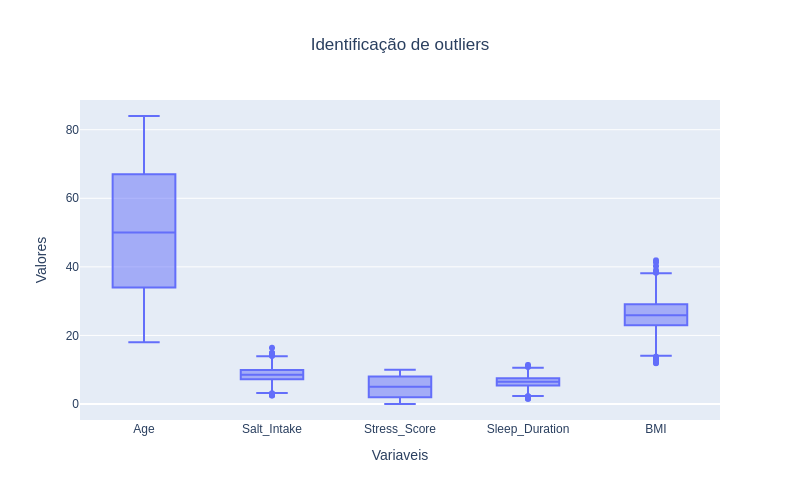

In [1349]:
# identificação de outliers nas variáveis não categóricas ou binárias
features = ["Age", "Salt_Intake", "Stress_Score", "Sleep_Duration", "BMI"]


# boxplot para visualização de outliers
fig = px.box(
    df[features],
    y=features,
    title="Identificação de outliers",
    width=800,
    height=500,
)
fig.update_layout(
    xaxis_title="Variaveis",
    yaxis_title="Valores",
    title_x=0.5,
)
fig.show()

In [1350]:
# exibição dos valores mínimos e máximos das variáveis analisadas
features = ["Salt_Intake", "Sleep_Duration", "BMI"]

for feature in features:
    print(
        f"{feature:<14} - Min: {df[feature].min():>5.2f}   Max: {df[feature].max():>5.2f}"
    )

Salt_Intake    - Min:  2.50   Max: 16.40
Sleep_Duration - Min:  1.50   Max: 11.40
BMI            - Min: 11.90   Max: 41.90


In [1351]:
df[features].describe()

,Salt_Intake,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000
mean,8.531688,6.452242,26.015315
std,1.994907,1.542207,4.512857
min,2.500000,1.500000,11.900000
25%,7.200000,5.400000,23.000000
50%,8.500000,6.500000,25.900000
75%,9.900000,7.500000,29.100000
max,16.400000,11.400000,41.900000


## 4. Definição do target, variáveis e divisão dos dados



In [1352]:
# definição do target e features
target = "Has_Hypertension"
features = [c for c in df.columns if c not in [target, "timestamp"]]

print("Target:", target)
print("N features:", len(features))

X = df[features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    # stratify=y,
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Target: Has_Hypertension
N features: 10
Treino: (1588, 10) | Teste: (397, 10)


In [1353]:
# transformação do target em valores numéricos
y = LabelEncoder().fit_transform(y)

### Tratamento de variáveis categóricas e variáveis numéricas

Variáveis categóricas devem ser transformadas em variáveis numéricas porque a maioria dos algoritmos de machine learning trabalha exclusivamente com números. Isso se aplica tanto a variáveis categóricas ordinais, que possuem uma ordem intrínseca (como “pequeno”, “médio”, “grande”), quanto a variáveis nominais, que não possuem nenhuma ordem (como “vermelho”, “azul”, “verde”) (Géron, 2022).

Variáveis ordinais, por terem uma ordem, podem ser convertidas para números inteiros. Por exemplo, a variável “tamanho” pode ser mapeada para 0 para “pequeno”, 1 para “médio” e 2 para “grande”. A classe OrdinalEncoder do Scikit-Learn é recomendada para essa tarefa, pois atribui um número inteiro único a cada categoria (Géron, 2022).

Para variáveis nominais, a simples conversão para números inteiros pode confundir os algoritmos, fazendo-os supor que os valores mais altos são "melhores" do que os mais baixos. Para evitar esse problema, o método mais comum é o One-Hot Encoding. Este método cria uma nova coluna binária (com valores 0 ou 1) para cada categoria da variável original (Géron, 2022).

Como técnica de tratamento das variáveis Estado Pressórico Anterior e Tipo de Medicação, por tratarem-se de variáveis categóricas não binárias, optou-se pelo emprego do método "One Hot Encoder", criando-se uma coluna binária para cada ocorrência de tipo categórico na variável. Além disso, ouptou-se pela remoção da primeira ocorrência na criação das novas variáveis binárias, de forma a evitar a multicolinearidade nos dados resultantes.

Já para as variáveis categóricas binárias Histórico Familiar de Hipertensão, Fumante ou não Fumante e Presença de Hipertensão (variável-alvo), optou-se pela adoção do método "Ordinal Encoder" em virtude da característica binária das mesmas, atribuindo-se o valor 0 para "não" e 1 para "sim".

Para a variável Nível de Atividade Física, apesar da mesma não se tratar de uma variável categórica binária, optou-se pelo emprego do método "Ordinal Encoder", ordenando-se suas categorias em Baixo, Moderado e Alto, de forma a dar sentido de sequêcia, atribuindo-se para as mesmas os valores 0, 1 e 2, respctivamente.

In [1354]:
# identificação de colunas numéricas
num_cols = [
    c for c in X_train.columns if str(X_train[c].dtype).startswith(("float", "int"))
]

# identificação de colunas categóricas binárias
cat_bin_cols = [
    c
    for c in X_train.columns
    if c not in num_cols and c != "timestamp" and X_train[c].unique().shape[0] == 2
]

# identificação de colunas categóricas múltiplas (mais de 2 categorias)
cat_mult_cols = [
    c
    for c in X_train.columns
    if c not in num_cols and c != "timestamp" and X_train[c].unique().shape[0] > 2
]


print(f"Variáveis Numéricas: {num_cols}")
print(f"Variáveis Categóricas Binárias: {cat_bin_cols}")
print(f"Variáveis Categóricas Múltiplas: {cat_mult_cols}")


# criação do pipeline de pré-processamento

# padronização das variáveis numéricas
num_pipe = Pipeline(steps=[("scaler", StandardScaler())])

# codificação das variáveis categóricas binárias
cat_bin_pipe = Pipeline(
    steps=[
        (
            "ordinal",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        )
    ]
)

# codificação das variáveis categóricas múltiplas
cat_mult_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing_value")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
        ),
    ]
)

# transformação das variáveis conforme seus tipos
transformer = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat_bin", cat_bin_pipe, cat_bin_cols),
        ("cat_mult", cat_mult_pipe, cat_mult_cols),
    ],
)

# pipeline completo de pré-processamento com PCA
preprocess = Pipeline(
    steps=[
        ("preprocessor", transformer),
        ("pca", PCA(n_components=13, random_state=SEED)),
        # ('std', StandardScaler()),  # PCA pode alterar a escala dos dados
    ]
)

print(f"\nFormato antes do PCA: {transformer.fit_transform(X_train).shape}")

preprocess

Variáveis Numéricas: ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']
Variáveis Categóricas Binárias: ['Family_History', 'Smoking_Status']
Variáveis Categóricas Múltiplas: ['BP_History', 'Medication', 'Exercise_Level']

Formato antes do PCA: (1588, 15)


,steps,"[('preprocessor', ...), ('pca', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [1355]:
preprocess.fit(X_train)

print(f"\nFormato após o PCA: {preprocess.transform(X_train).shape}")

display(pd.DataFrame(preprocess.transform(X_train)).head(5))

print(pd.DataFrame(preprocess.transform(X_train)).info())


Formato após o PCA: (1588, 13)


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.001287,0.776227,-0.283787,-0.617383,0.624419,-0.783624,0.589452,-0.707034,-0.689313,0.688484,0.486554,-0.026652,0.148826
1,-1.177733,0.196485,-2.260916,-1.011891,1.068001,0.567435,0.621236,0.638575,0.528458,-0.178170,0.139268,0.064542,0.084715
2,0.225869,0.605911,-0.357453,0.760689,0.202280,-0.856965,-0.796476,0.513282,0.552226,-0.246597,0.201126,0.040726,0.196119
3,1.450675,1.454649,0.107127,-0.024488,-0.406997,-0.926102,-0.860662,0.463750,0.497305,0.744339,0.062866,0.034683,0.212677
4,0.618357,0.280624,1.272527,-0.409460,0.037058,0.625863,-0.092730,-0.317524,-0.420424,-0.435326,-0.744971,-0.677803,-0.258928


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1588 entries, 0 to 1587
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1588 non-null   float64
 1   1       1588 non-null   float64
 2   2       1588 non-null   float64
 3   3       1588 non-null   float64
 4   4       1588 non-null   float64
 5   5       1588 non-null   float64
 6   6       1588 non-null   float64
 7   7       1588 non-null   float64
 8   8       1588 non-null   float64
 9   9       1588 non-null   float64
 10  10      1588 non-null   float64
 11  11      1588 non-null   float64
 12  12      1588 non-null   float64
dtypes: float64(13)
memory usage: 161.4 KB
None


## 6. Baseline e modelos candidatos

In [1356]:
# definição de parâmetros do classificador
num_trees = 100

baseline = Pipeline(
    steps=[
        ("pre", preprocess),
        ("model", DummyClassifier(strategy="stratified", random_state=SEED)),
    ]
)


candidates = {
    "LR": Pipeline(
        [
            ("pre", preprocess),
            ("model", LogisticRegression(random_state=SEED, max_iter=200)),
        ]
    ),
    "DT": Pipeline(
        [("pre", preprocess), ("model", DecisionTreeClassifier(random_state=SEED))]
    ),
    "RF": Pipeline(
        [
            ("pre", preprocess),
            (
                "model",
                RandomForestClassifier(random_state=SEED, n_estimators=num_trees),
            ),
        ]
    ),
    "KNN": Pipeline([("pre", preprocess), ("model", KNeighborsClassifier())]),
    "GNB": Pipeline([("pre", preprocess), ("model", GaussianNB())]),
    "SVM": Pipeline([("pre", preprocess), ("model", SVC(random_state=SEED))]),
    "ADA": Pipeline(
        [
            ("pre", preprocess),
            ("model", AdaBoostClassifier(random_state=SEED, n_estimators=num_trees)),
        ]
    ),
    "ET": Pipeline(
        [
            ("pre", preprocess),
            (
                "model",
                ExtraTreesClassifier(random_state=SEED, n_estimators=num_trees),
            ),
        ]
    ),
    "BAG": Pipeline(
        [
            ("pre", preprocess),
            (
                "model",
                BaggingClassifier(random_state=SEED, n_estimators=num_trees),
            ),
        ]
    ),
    "GB": Pipeline(
        [
            ("pre", preprocess),
            (
                "model",
                GradientBoostingClassifier(random_state=SEED, n_estimators=num_trees),
            ),
        ]
    ),
}

In [1357]:
results = {}

# treinamento e avaliação do modelo baseline
t0 = time.time()
baseline.fit(X_train, y_train)
t1 = time.time()

y_pred = baseline.predict(X_test)

proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None

results["baseline"] = evaluate_classification(y_test, y_pred, proba)
results["baseline"]["train_time_s"] = round(t1 - t0, 3)


# treinamento e avaliação dos modelos candidatos
for name, pipe in candidates.items():

    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()

    y_pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
    results[name] = evaluate_classification(y_test, y_pred, proba)
    results[name]["train_time_s"] = round(t1 - t0, 3)


# exibição dos resultados
pd.DataFrame(results).T.sort_values(by="recall_score", ascending=False)

,accuracy,f1_score,recall_score,precision_score,roc_auc,train_time_s
GB,0.901763,0.901786,0.901763,0.902735,0.964050,0.681
SVM,0.899244,0.899225,0.899244,0.899252,NaN,0.053
ADA,0.896725,0.896752,0.896725,0.897062,0.965295,0.396
RF,0.894207,0.894235,0.894207,0.894671,0.961433,0.420
BAG,0.891688,0.891717,0.891688,0.892300,0.958168,1.114
LR,0.879093,0.879110,0.879093,0.879172,0.956784,0.047
ET,0.874055,0.874079,0.874055,0.875213,0.953392,0.154
GNB,0.869018,0.868978,0.869018,0.871767,0.939583,0.011
DT,0.828715,0.828739,0.828715,0.828805,0.828697,0.039
KNN,0.811083,0.811002,0.811083,0.813902,0.895236,0.013


## 7. Validação e Otimização de Hiperparâmetros

In [1360]:
# definição de parâmetros para a validação cruzada
n_folds = 10  # número de folds da validação cruzada (3, 5, 10)
scorer = "accuracy"

cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
model = Pipeline(
    [
        ("pre", preprocess),
        # ("model", AdaBoostClassifier(random_state=SEED)),
        ("model", GradientBoostingClassifier(random_state=SEED)),
    ]
)
param_dist = {
    "model__n_estimators": [250, 300, 350],
    "model__learning_rate": [1.0, 1.5],
    "model__max_depth": [3, 4],
    # "model__max_features": ["auto", "sqrt", "log2"],
}

In [1361]:
search = GridSearchCV(
    model,
    param_grid=param_dist,
    cv=cv,
    scoring=scorer,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)
print("Melhor score (CV):", search.best_score_)
print("Melhores parâmetros:", search.best_params_)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Melhor score (CV): 0.8929105962901043
Melhores parâmetros: {'model__learning_rate': 1.0, 'model__max_depth': 3, 'model__n_estimators': 300}


## 8. Avaliação final, análise de erros e limitações

              precision    recall  f1-score   support

          No       0.87      0.90      0.88       192
         Yes       0.90      0.88      0.89       205

    accuracy                           0.89       397
   macro avg       0.89      0.89      0.89       397
weighted avg       0.89      0.89      0.89       397



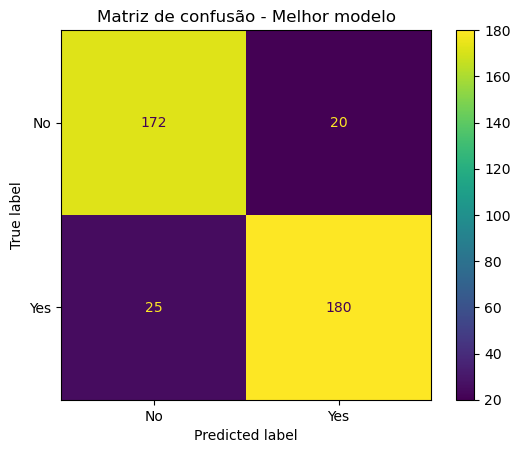

In [1362]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))
try:
    ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
    plt.title("Matriz de confusão - Melhor modelo")
    plt.show()
except Exception as e:
    print("Não foi possível plotar a matriz de confusão:", e)

## Referências

BROWNLEE, Jason. **Machine Learning Mastery with Python Understand Your Data, Create Accurate Models and Work Projects End-To-End**. 1. ed. Austrália: Machine Learning Mastery, 2016.

GALLATIN, K.; ALBON, C.. **Machine Learning with Python Cookbook Practical Solutions from Preprocessing to Deep Learning**. 2. ed. O'Reilly, 2023.

GÉRON, Aurélien. **Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow**. 3. ed. Sebastopol, CA: O'Reilly Media, 2022.

MUKHOPADHYAY, Sayan. **Advanced Data Analytics Using Python**. Apress, 2018.